In [46]:
from scipy.io import loadmat
import numpy as np
from SolveTriangular import *
from numpy import linalg as lin
from scipy import linalg as splin
from numpy.linalg import norm
import matplotlib.pyplot as plt
from numpy.linalg import matrix_rank as rank

err_rel = lambda x, px: norm(x-px, 2) / norm(x, 2)
K = lambda A: norm(A) * norm(splin.inv(A))

data = loadmat('test_II.mat')
A = data['A']
A = A.astype(float)
b = data['b']
b = b.astype(float)

auto = lin.eigvals(A)
assert np.allclose(A, A.copy().T)
assert all(np.r_[np.isreal(auto), auto > 0])

def cho_solve(A, b):
    L = lin.cholesky(A)
    return Usolve(L.copy().T, Lsolve(L, b))

def LU_solve(A, b):
    PT, L, U = splin.lu(A)
    P = PT.copy().T
    return Usolve(U, Lsolve(L, P @ b))

def QR_solve(A, b):
    Q, R = splin.qr(A)
    return Usolve(R, Q.copy().T @ b)

cho_s = cho_solve(A, b)
lu_s = LU_solve(A, b)
qr_s = QR_solve(A, b)
s1 = splin.solve(A, b)
real = np.ones(len(b))

print(f'Errore relativo di cholesxy rispetto alla soluzione {err_rel(real, cho_s)}')
print(f'Errore relativo di gauss rispetto alla soluzione {err_rel(real, lu_s)}')
print(f'Errore relativo di householder rispetto alla soluzione {err_rel(real, qr_s)}')

print(f'Errore di condizionamento → {K(A)}')



Errore relativo di cholesxy rispetto alla soluzione 1.7501425609228122e-16
Errore relativo di gauss rispetto alla soluzione 1.9173458420030424e-16
Errore relativo di householder rispetto alla soluzione 3.9642891350404605e-16
Errore di condizionamento → 456.6449068783211


## Esercizio 2


In [82]:
def lagrange(xnodi: np, j: int):
    num = np.poly(xnodi[xnodi != xnodi[j]])
    den = np.polyval(num, xnodi[j])
    return num / den

def interL(x, y, xv):
    La = np.array([np.polyval(lagrange(x, j), xv) for j in range(len(x))])
    return La.T @ y

In [83]:
def plot_interpolation(x, y, n):
    xv = np.linspace(min(x), max(x), 100)
    res = interL(x, y, xv)
    plt.plot(xv, res, label='interL')

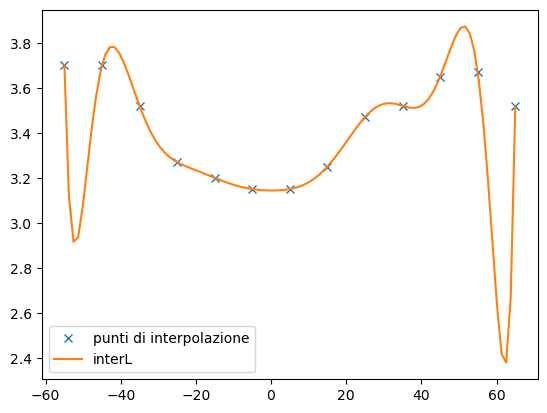

In [84]:
L = np.arange(-55, 75, 10)
T = np.array([3.7, 3.7, 3.52, 3.27, 3.2, 3.15, 3.15, 3.25, 3.47, 3.52, 3.65, 3.67, 3.52]) 

plt.plot(L, T, 'x', label='punti di interpolazione')
n = 12
plot_interpolation(L, T, n)
plt.legend()

## Regressione

In [85]:
def qrLS(A, b):
    Q, R = splin.qr(A)
    R1 = R[0:n,:]
    h = Q.T @ b
    print(f'\nCondizionamento di R → {lin.cond(R1)}')
    print(f'Residuo → {lin.norm(h[n:])**2}')
    return Usolve(R1, h[0:n])

def plot_regression(x, y, A):
    xv = np.linspace(min(x), max(x), 100)
    plt.plot(x, y, 'x', label='dati sperimentali')
    alfa = svdLS(A, y)
    regression = np.polyval(np.flip(alfa), xv)
    plt.plot(xv, regression, label='qrLS')
    plt.title("Regressione")
    plt.legend()
    plt.show()

Condizionamento di A → 748849872.1584762

Diciamo che la matrice e mal condizionata e dunque non possiamo
Usare il metodo delle equazioni normali

Matrice ha rango massimo (6 == 6) e dunque qr e svdls sono utilizzabili

Metodo Singular Value Decomposition (Least Squared)
Condizionamento di A: 7.488e+08
Residuo → 0.009427272727272753


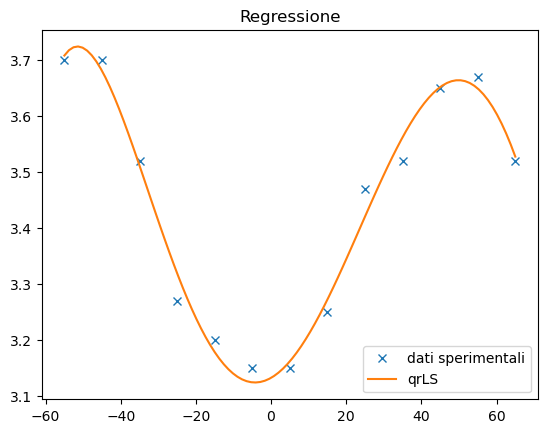

In [87]:

n = 5
A = np.vander(L, increasing=True)[:,:n+1]
m, n = A.shape
print(f'Condizionamento di A → {lin.cond(A)}\n')
print('Diciamo che la matrice e mal condizionata e dunque non possiamo\nUsare il metodo delle equazioni normali')
if rank(A) < n:
    print("\nMatrice non ha rango massimo e dunque qr e inutilizzabile")
else:
    print(f"\nMatrice ha rango massimo ({rank(A)} == {n}) e dunque qr e svdls sono utilizzabili")

plot_regression(L, T, A)
